In [1]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [2]:
setwd(data_dir)

In [28]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)


In [29]:
# Load the data from your txt file
file_path <- "SVs_merged_all_samples_SVs_v7.txt"
data <- read.table(file_path, header = TRUE, sep = "\t")
head(data)

,chr,start,end,size,type,filename,arm
,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>
1,chr1,54754,54755,38,INS,3988,p
2,chr1,66252,66253,247,INS,3988,p
3,chr1,67911,68342,431,DEL,3988,p
4,chr1,83975,83976,63,INS,3988,p
5,chr1,136935,136936,244,INS,3988,p
6,chr1,180089,180090,1,BND,3988,p


In [12]:
summary_stats <- data %>%
  group_by(filename) %>%
  summarise(n_variants = n()) %>%
  summarise(
    mean_variants = mean(n_variants),
    min_variants  = min(n_variants),
    max_variants  = max(n_variants),
    n_samples     = n()
  )

summary_stats


mean_variants,min_variants,max_variants,n_samples
<dbl>,<int>,<int>,<int>
29311.05,20834,33876,20


In [13]:

#data <- data %>%
 # dplyr::rename(filename = sample)
#head(data)

In [14]:
data <- data %>%
  mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  filter(size > 0)  # Only keep rows where the size is greater than 0

# Show the first few rows of the data
head(data)

# Save to a tab-separated file
#write.table(data, "/home/mjehangir/data_analysis/glioma_project_data_analysis/glioma_project/SV_analysis/sniffles_merged_all_samples_SVs_v8.txt", 
            #sep = "\t", row.names = FALSE)


,chr,start,end,size,type,filename,arm
,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,chr1,54754,54755,1,INS,3988,p
2,chr1,66252,66253,1,INS,3988,p
3,chr1,67911,68342,431,DEL,3988,p
4,chr1,83975,83976,1,INS,3988,p
5,chr1,136935,136936,1,INS,3988,p
6,chr1,180089,180090,1,BND,3988,p


In [15]:
# Step 1: Filter the data to keep only chromosomes from chr1 to chr22
data <- data %>%
  filter(chr %in% paste0("chr", 1:22))  # Filter out chrX, chrY, chrM

# Step 2: Total SVs per sample bar plot (raw count, ordered descending)
total_SVs <- data %>%
  group_by(filename) %>%
  summarize(Total_SV = n())  # Count number of SVs per sample

# Sort samples by total SV count (descending order)
sorted_samples <- total_SVs %>%
  arrange(desc(Total_SV)) %>%
  pull(filename)

options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

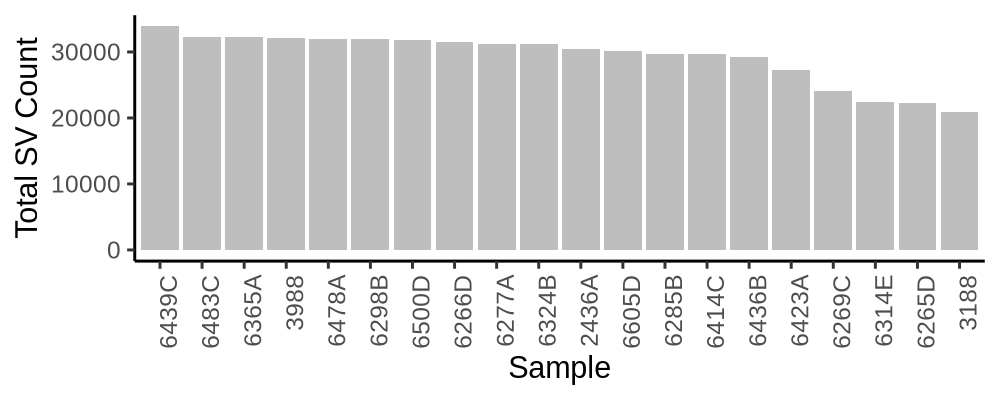

In [16]:
# Barplot for total SV count per sample (ordered descending)
ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


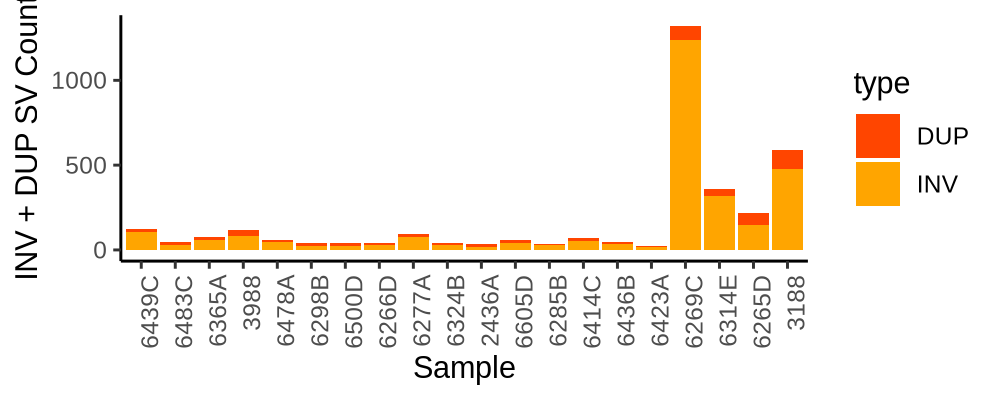

In [17]:
# Step 3: Stacked bar plot by SV types (combining INV + DUP and DEL + INS into separate plots)
# INV + DUP combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


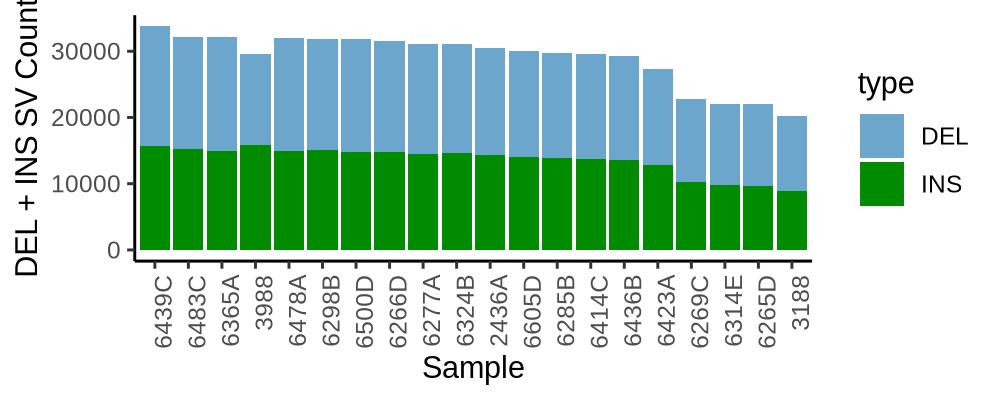

In [18]:
# DEL + INS combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

In [19]:
head(total_SVs)

filename,Total_SV
<chr>,<int>
2436A,30490
3188,20834
3988,32083
6265D,22283
6266D,31526
6269C,24048


In [20]:
total_svs_sorted <- total_SVs %>%
  arrange(desc(Total_SV))

print(total_svs_sorted)

# A tibble: 20 × 2
   filename Total_SV
   <chr>       <int>
 1 6439C       33876
 2 6483C       32254
 3 6365A       32212
 4 3988        32083
 5 6478A       31985
 6 6298B       31927
 7 6500D       31873
 8 6266D       31526
 9 6277A       31176
10 6324B       31154
11 2436A       30490
12 6605D       30088
13 6285B       29701
14 6414C       29700
15 6436B       29284
16 6423A       27337
17 6269C       24048
18 6314E       22390
19 6265D       22283
20 3188        20834


In [21]:

# Step 1: Total SV Count per Sample Plot (ordered descending)
total_SV_plot <- ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

#ggsave("Total_SV_Count_v2.pdf", plot = total_SV_plot, height = 6, width = 10)  # Save as PDF with v2 naming

# Step 2: INV + DUP Combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

INV_DUP_plot <- ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

#ggsave("INV_DUP_SV_Count_v2.pdf", plot = INV_DUP_plot, height = 6, width = 10)  # Save as PDF with v2 naming

# Step 3: DEL + INS Combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

DEL_INS_plot <- ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

#ggsave("DEL_INS_SV_Count_v2.pdf", plot = DEL_INS_plot, height = 6, width = 10)  # Save as PDF with v2 naming


`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


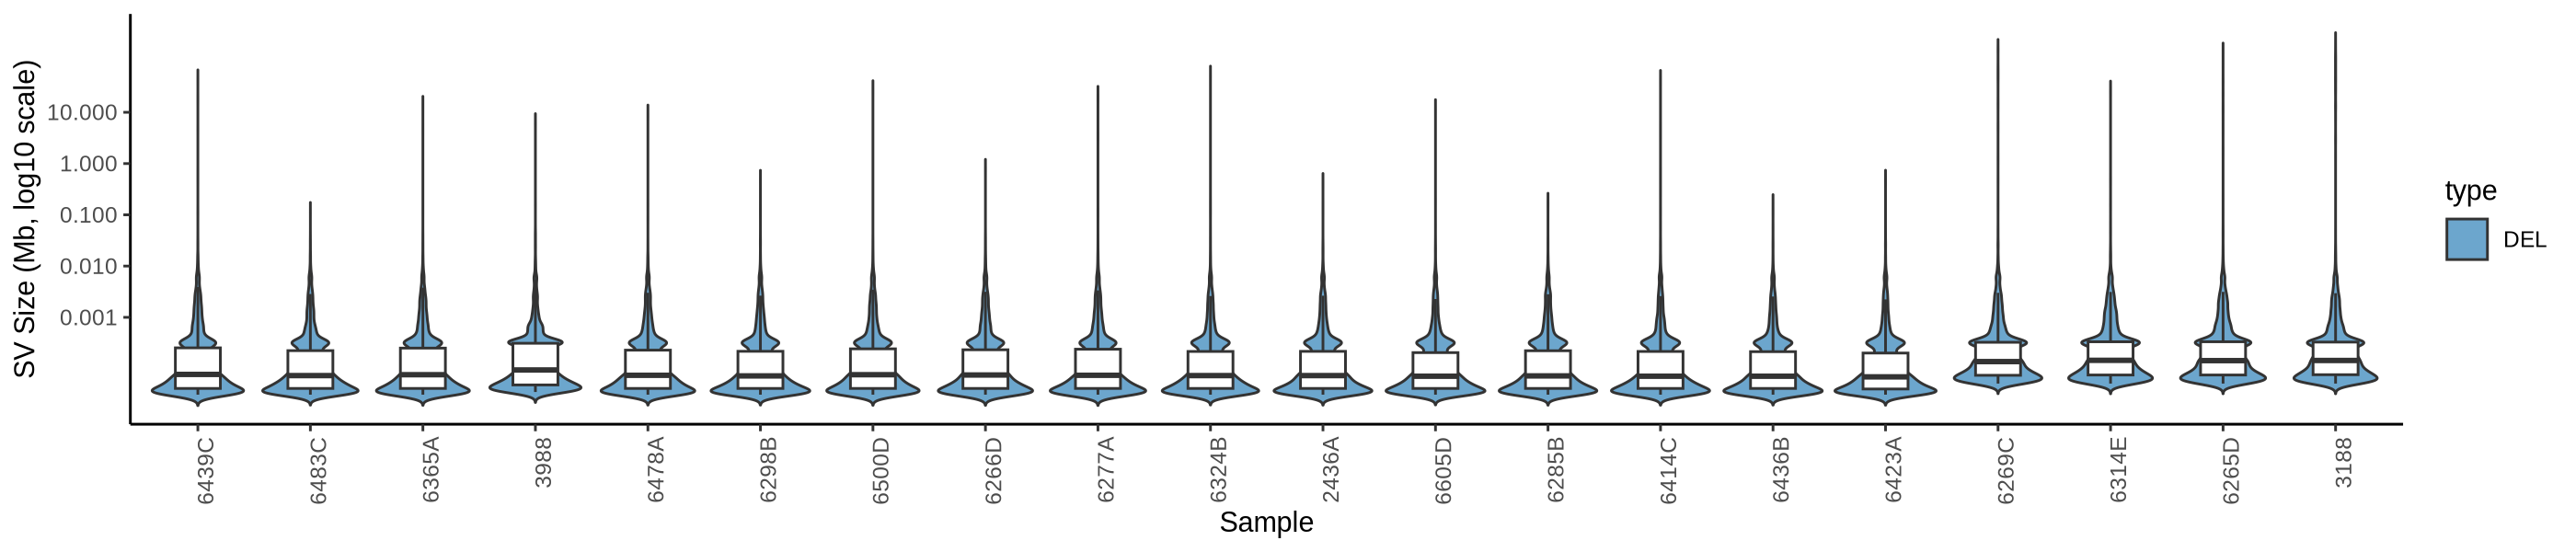

In [22]:

options(repr.plot.width = 14, repr.plot.height = 3, repr.plot.res = 200)

del_violin_plot<-ggplot(data %>% filter(type == "DEL"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1, 10), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DEL" = "skyblue3")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
print(del_violin_plot)
# Save the plot to the specified directory
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/DEL_SV_Size_violin_v2.pdf", plot = del_violin_plot, height = 6, width = 14)


In [23]:
dup_violin_plot<-ggplot(data %>% filter(type == "DUP"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DUP" = "orangered")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/DUP_SV_Size_violin_v2.pdf", plot = dup_violin_plot, height = 6, width = 14)


In [24]:
inv_violin_plot<-ggplot(data %>% filter(type == "INV"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 1) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.1, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INV" = "orange")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/INV_SV_Size_violin_v2.pdf", plot = inv_violin_plot, height = 6, width = 14)


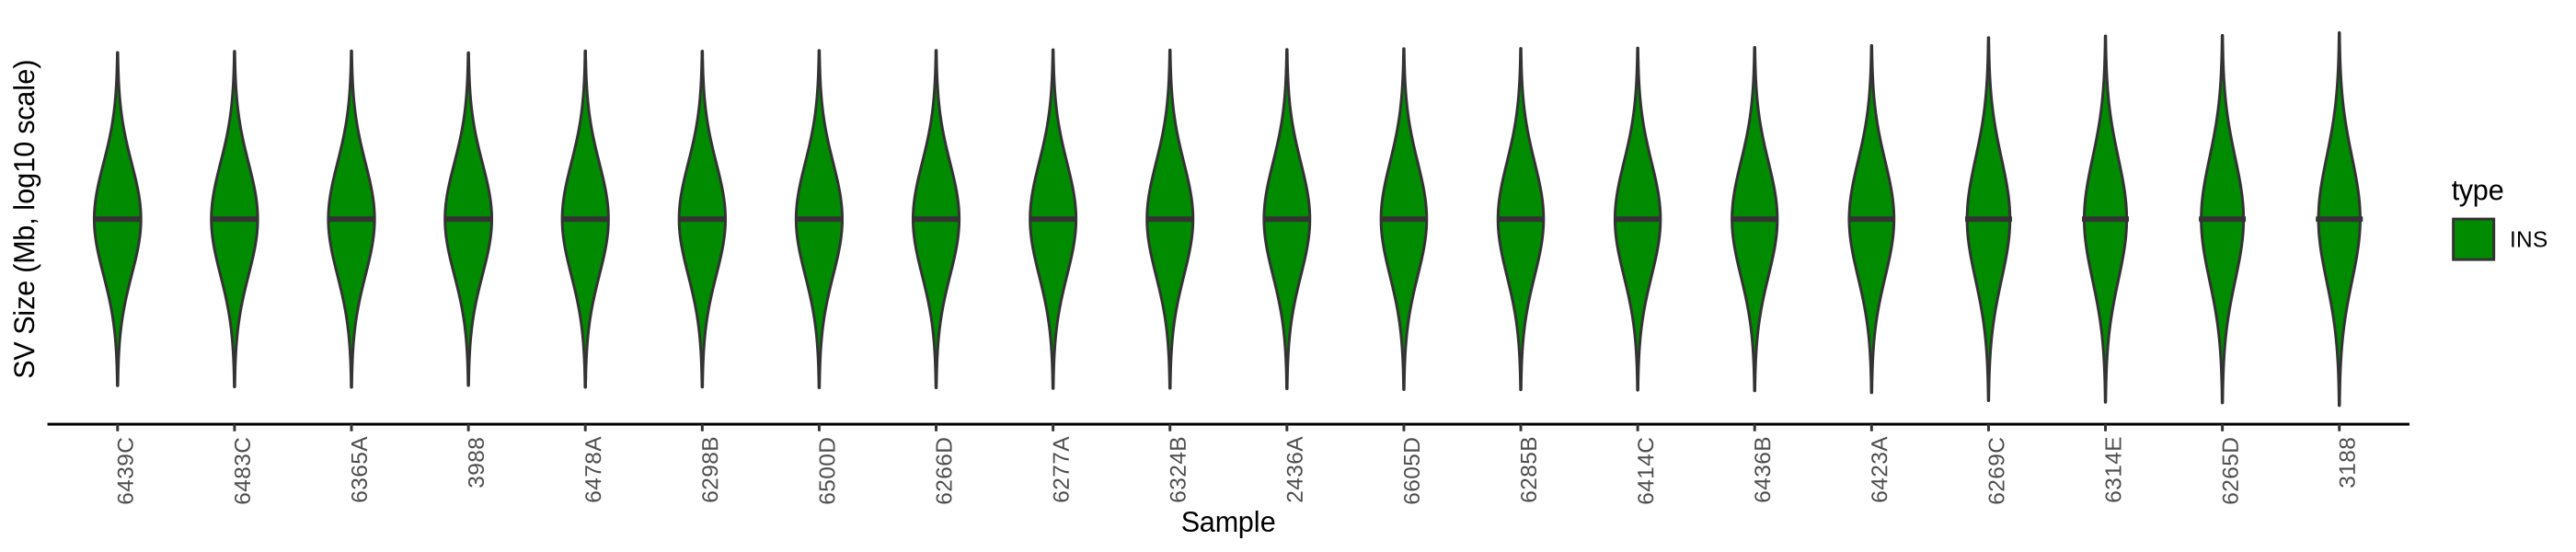

In [26]:
ins_violin_plot<-ggplot(data %>% filter(type == "INS"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 0.4) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INS" = "green4")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/INS_SV_Size_violin_v2.pdf", plot = ins_violin_plot, height = 6, width = 14)
ins_violin_plot

In [41]:
# Filter out BND SVs
data_filtered <- data %>% filter(type != "BND")

# Ensure correct column name for SV length
# If 'SV_length' does not exist, replace with the actual column name (e.g., 'size')
sv_summary <- data_filtered %>%
  group_by(filename, type) %>%
  summarize(SV_length = sum(size), .groups = "drop")  # Change 'size' if needed

# Convert SV length to log10 scale
sv_summary <- sv_summary %>%
  mutate(SV_length_log10 = log10(SV_length))

In [42]:
head(data_filtered)

,chr,start,end,size,type,filename,arm
,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,chr1,54754,54755,1,INS,3988,p
2,chr1,66252,66253,1,INS,3988,p
3,chr1,67911,68342,431,DEL,3988,p
4,chr1,83975,83976,1,INS,3988,p
5,chr1,136935,136936,1,INS,3988,p
6,chr1,180608,180652,44,DEL,3988,p


In [43]:
nrow(data_filtered)

[1] 583827

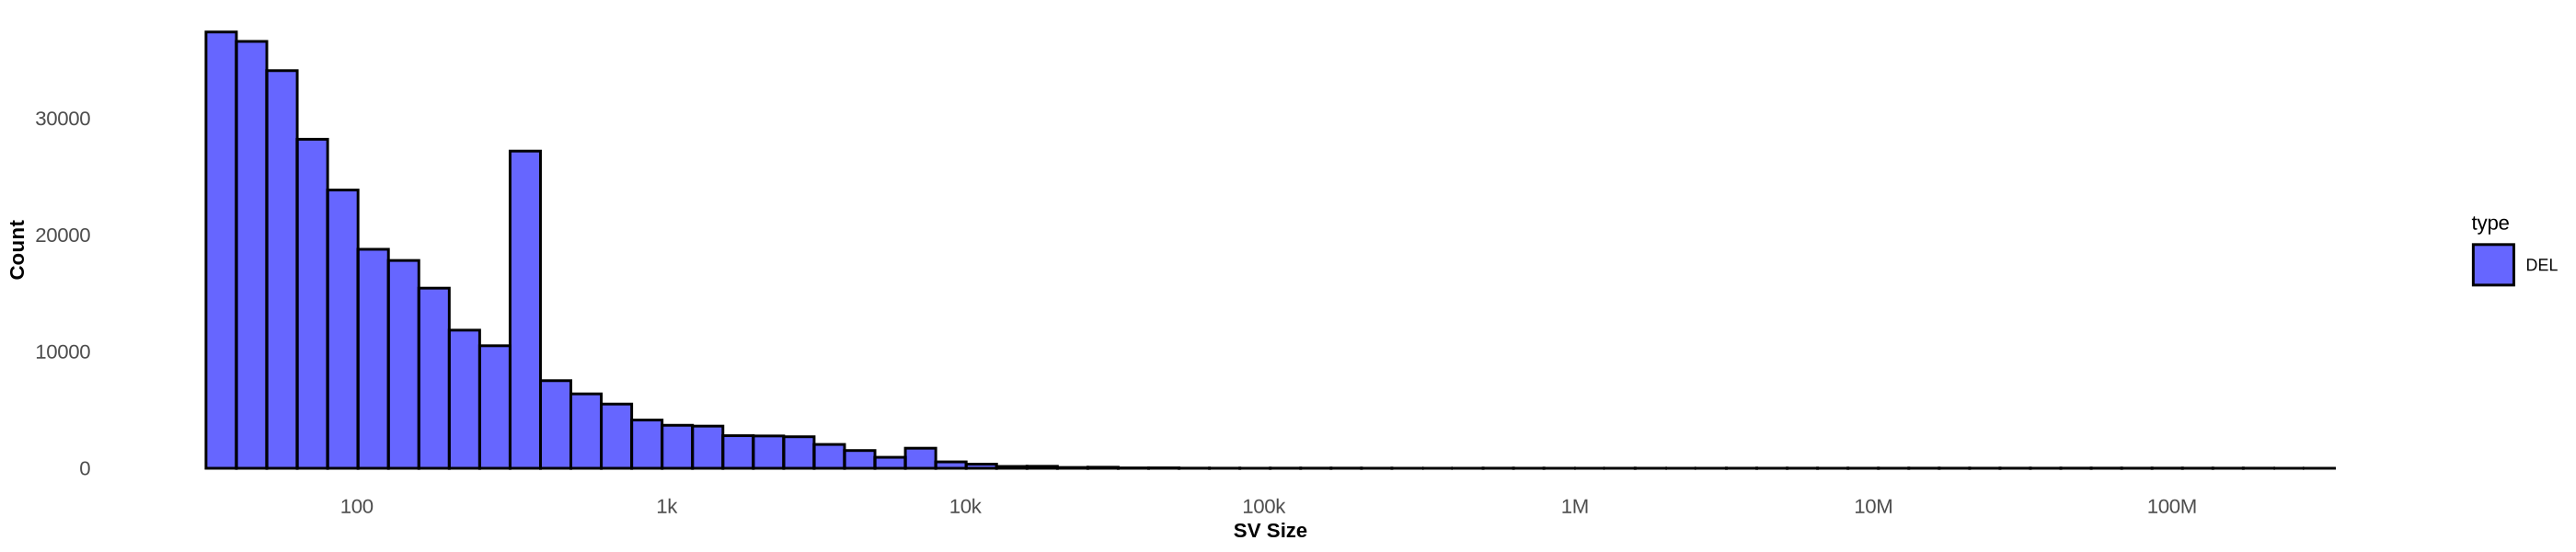

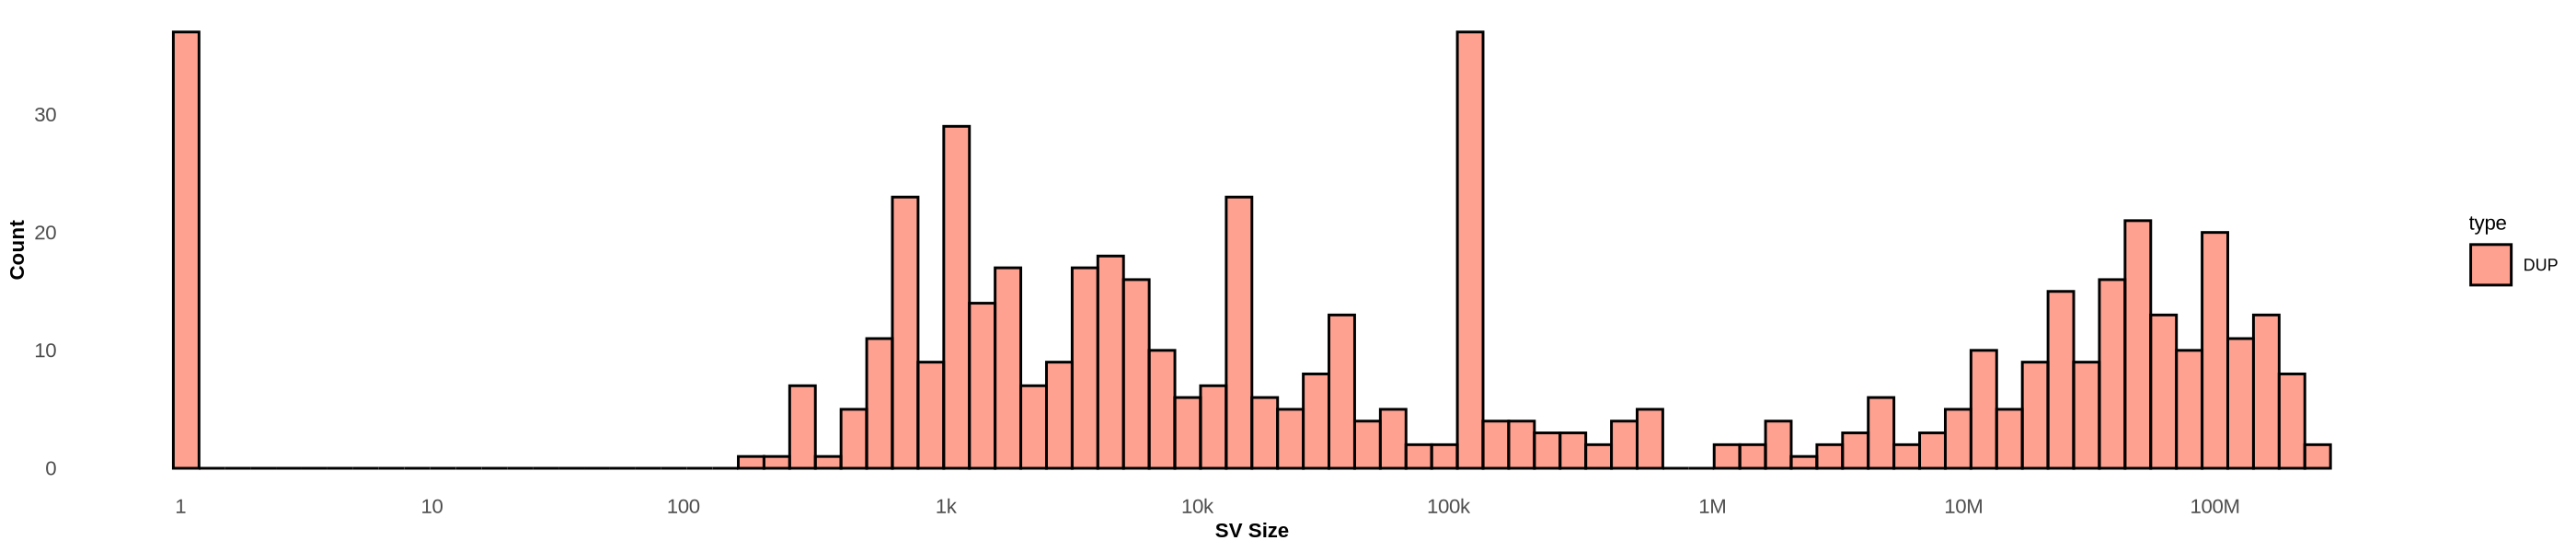

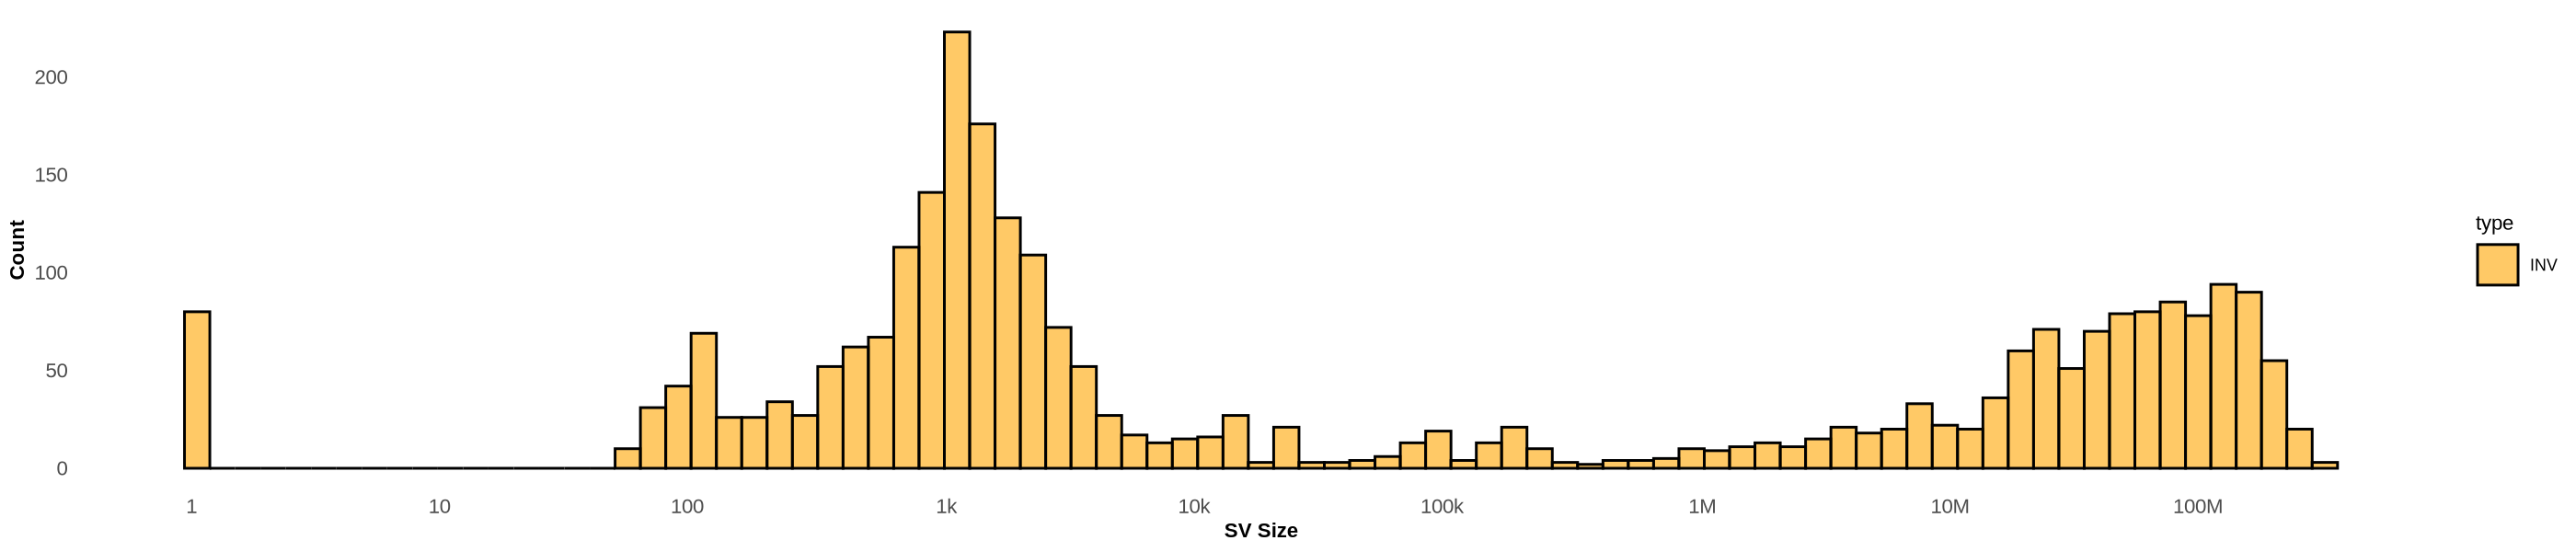

In [27]:
plot_sv_histogram <- function(sv_type, color) {
  ggplot(data %>% filter(type == sv_type), 
         aes(x = size, fill = type)) +
    geom_histogram(binwidth = 0.1, alpha = 0.6, position = "identity", color = "black") +  # Histogram with binwidth of 0.1
    scale_x_continuous(trans = "log10", 
                       breaks = c(1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000),  # Log scale breaks up to 10M
                       labels = function(x) {
                         # Handle custom labels based on magnitude
                         sapply(x, function(val) {
                           if (is.na(val)) {
                             return(NA)  # Return NA if the value is not numeric
                           } else if (val < 1000) {
                             return(paste0(val))  # No scaling for values < 1k
                           } else if (val >= 1000 && val < 10000) {
                             return(paste0(val / 1000, "k"))  # Values between 1k and 10k
                           } else if (val >= 10000 && val < 100000) {
                             return(paste0(val / 1000, "k"))  # Values between 10k and 100k
                           } else if (val >= 100000 && val < 1000000) {
                             return(paste0(val / 1000, "k"))  # Values between 100k and 1M
                           } else if (val >= 1000000 && val < 10000000) {
                             return(paste0(val / 1000000, "M"))  # Values between 1M and 10M
                           } else {
                             return(paste0(val / 1000000, "M"))  # For values >= 10M
                           }
                         })
                       }) +  # Custom labels for x-axis based on size
    scale_fill_manual(values = setNames(color, sv_type)) +
    labs(x = "SV Size", y = "Count") +
    theme_minimal(base_size = 8) +  # Clean theme with larger text
    theme(axis.text.x = element_text(angle = 0, hjust = 1),  # Angle x-axis labels for better readability
          axis.title.x = element_text(face = "bold"),  # Bold x-axis label
          axis.title.y = element_text(face = "bold"),  # Bold y-axis label
          axis.text = element_text(size = 8),  # Increase text size
          panel.grid.major = element_blank(),  # Remove major grid lines for a cleaner look
          panel.grid.minor = element_blank(),  # Remove minor grid lines
          plot.title = element_text(face = "bold", hjust = 0.5))  # Centered title
}
#options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

#pdf("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/plot_sv_histogram_v2.pdf", height = 6, width = 14)

# Call your plotting function for each SV type
plot_sv_histogram("DEL", "blue")  # Deletions
plot_sv_histogram("DUP", "tomato")   # Duplications
plot_sv_histogram("INV", "orange") # Inversions

#dev.off()  # Close the PDF device
